# Cash Flow Intelligence: Financial Diagnostics & Revenue Forecasting

**Project Overview:**
This project analyzes 7 years of monthly financial data (2018-2024) for a small Indian consulting/marketing agency (10-18 employees), diagnosing cash flow health and forecasting revenue.

**What's covered:**
* Data cleaning of a realistically messy dataset (mixed date formats, currency strings, missing values, duplicate records)
* Exploratory analysis of revenue, expenses, profitability, and collections
* Time series decomposition to separate trend from seasonality
* Anomaly detection to flag genuine outlier months
* Revenue forecasting with ARIMA and SARIMA, compared and cross-validated
* Business recommendations grounded in the data, not assumptions

**The core question:** the business is profitable on paper, so why does its cash position tell a different story? This notebook works through that gap end to end, from raw data to a forecast a business could actually plan around.

In [1]:
# importing the libraries we'll need
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# loading in the dataset
df=pd.read_csv("sme_agency_financials_v3.csv")

### Basic Checks

In [3]:
df.head()

,month,revenue_billed,cash_collected,collection_rate,accounts_receivable,active_clients,new_clients,headcount,payroll_expense,rent_expense,software_expense,marketing_expense,utilities_expense,misc_expense,one_off_expense,total_operating_expense,gross_profit,net_profit,cash_balance
0,2019-02-01,449075.27,403718.67,0.899,495444.82,20,3,11,219030.01,45000,20114.76,32260.33,8063.58,8315.69,0.0,332784.37,116290.90,116290.90,906616.94
1,2021-10-01,1560764.86,522551.19,0.335,3371133.47,30,2,14,496101.89,45000,23707.27,47341.14,8684.72,9741.33,0.0,630576.35,930188.51,930188.51,1597306.30
2,2019-06-01,"₹456,747.88",411986.59,0.902,646638.07,21,2,11,228262.09,45000,20258.66,31671.56,7925.57,12467.90,0.0,345585.78,111162.10,111162.10,968355.56
3,"September 01, 2019",464779.18,432244.64,0.930,546808.05,22,4,12,246219.46,45000,19398.01,38664.54,8168.06,8009.49,0.0,365459.56,99319.62,99319.62,1086416.22
4,2019-01-01,423601.0,385053.31,0.909,799704.33,22,5,11,191351.90,45000,19754.99,31673.87,7868.24,14585.59,0.0,310234.59,113366.41,113366.41,835682.64


In [4]:
df.tail()

,month,revenue_billed,cash_collected,collection_rate,accounts_receivable,active_clients,new_clients,headcount,payroll_expense,rent_expense,software_expense,marketing_expense,utilities_expense,misc_expense,one_off_expense,total_operating_expense,gross_profit,net_profit,cash_balance
80,2019-12-01,"₹496,650.80",465361.80,0.937,672312.12,25,3,12,250703.71,45000,19798.69,43962.36,8371.54,13674.91,0.00,381511.21,115139.59,115139.59,1270056.89
81,2023-08-01,"₹663,469.48",616363.15,0.929,660504.80,35,2,16,366563.15,50000,27363.03,50638.02,9614.28,10127.32,0.00,514305.80,149163.68,149163.68,1341914.54
82,2020-02-01,465857.34,402966.60,0.865,574485.04,26,1,12,236806.37,45000,21288.63,29985.39,8142.71,10911.44,0.00,352134.54,113722.80,113722.80,1275781.41
83,2023-09-01,627639.07,539769.60,0.860,879877.91,36,2,16,364858.21,50000,27928.19,45756.27,9100.06,5509.60,76140.53,579292.86,48346.21,48346.21,1240515.25
84,2021-12-01,589221.78,553279.25,0.939,760647.46,31,5,14,295777.12,45000,24032.44,56563.76,8601.56,13373.82,0.00,443348.70,145873.08,145873.08,1466613.41


In [5]:
df.shape

(85, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    85 non-null     object 
 1   revenue_billed           85 non-null     object 
 2   cash_collected           85 non-null     float64
 3   collection_rate          85 non-null     float64
 4   accounts_receivable      85 non-null     float64
 5   active_clients           85 non-null     int64  
 6   new_clients              85 non-null     int64  
 7   headcount                85 non-null     int64  
 8   payroll_expense          85 non-null     float64
 9   rent_expense             85 non-null     int64  
 10  software_expense         81 non-null     float64
 11  marketing_expense        81 non-null     float64
 12  utilities_expense        81 non-null     float64
 13  misc_expense             81 non-null     float64
 14  one_off_expense          81 

In [7]:
df.columns.tolist()

['month',
 'revenue_billed',
 'cash_collected',
 'collection_rate',
 'accounts_receivable',
 'active_clients',
 'new_clients',
 'headcount',
 'payroll_expense',
 'rent_expense',
 'software_expense',
 'marketing_expense',
 'utilities_expense',
 'misc_expense',
 'one_off_expense',
 'total_operating_expense',
 'gross_profit',
 'net_profit',
 'cash_balance']

### Data Quality Checks

In [8]:
df.dtypes

month                       object
revenue_billed              object
cash_collected             float64
collection_rate            float64
accounts_receivable        float64
active_clients               int64
new_clients                  int64
headcount                    int64
payroll_expense            float64
rent_expense                 int64
software_expense           float64
marketing_expense          float64
utilities_expense          float64
misc_expense               float64
one_off_expense            float64
total_operating_expense    float64
gross_profit               float64
net_profit                 float64
cash_balance               float64
dtype: object

In [9]:
df.isnull().sum()

month                      0
revenue_billed             0
cash_collected             0
collection_rate            0
accounts_receivable        0
active_clients             0
new_clients                0
headcount                  0
payroll_expense            0
rent_expense               0
software_expense           4
marketing_expense          4
utilities_expense          4
misc_expense               4
one_off_expense            4
total_operating_expense    0
gross_profit               0
net_profit                 0
cash_balance               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,cash_collected,collection_rate,accounts_receivable,active_clients,new_clients,headcount,payroll_expense,rent_expense,software_expense,marketing_expense,utilities_expense,misc_expense,one_off_expense,total_operating_expense,gross_profit,net_profit,cash_balance
count,85.000000,85.000000,8.500000e+01,85.000000,85.000000,85.000000,85.000000,85.000000,81.000000,81.000000,81.000000,81.000000,81.000000,8.500000e+01,85.000000,85.000000,8.500000e+01
mean,496086.035882,0.886012,7.565329e+05,29.235294,2.788235,13.388235,304409.292588,47117.647059,23963.910864,42948.295556,8761.594568,10671.126790,33639.546914,4.658651e+05,110890.659412,110890.659412,1.227127e+06
std,89283.622085,0.092571,5.448478e+05,6.702251,1.225659,3.786235,85749.441069,2485.250609,3982.839373,10545.541088,559.863127,2687.328771,112595.814120,1.564581e+05,170769.844893,170769.844893,3.554204e+05
min,356662.270000,0.330000,3.249096e+05,17.000000,1.000000,-13.000000,180593.570000,45000.000000,17335.110000,25610.850000,7633.290000,5045.000000,0.000000,2.731210e+05,-600308.990000,-600308.990000,3.615758e+05
25%,422207.840000,0.865000,5.262005e+05,24.000000,2.000000,12.000000,236806.370000,45000.000000,20159.010000,34030.720000,8371.540000,8336.380000,0.000000,3.564829e+05,102297.760000,102297.760000,9.907022e+05
50%,482752.730000,0.902000,6.573072e+05,29.000000,3.000000,14.000000,289021.070000,45000.000000,24442.830000,41488.200000,8759.730000,10911.440000,0.000000,4.433487e+05,116290.900000,116290.900000,1.242923e+06
75%,556916.400000,0.929000,7.997043e+05,35.000000,4.000000,16.000000,368236.980000,50000.000000,27440.730000,50638.020000,9194.150000,12968.170000,0.000000,5.376390e+05,136103.320000,136103.320000,1.518789e+06
max,684624.470000,0.949000,4.506077e+06,41.000000,5.000000,18.000000,612313.610000,50000.000000,30775.440000,70877.110000,9848.310000,14987.430000,733207.610000,1.300540e+06,935159.920000,935159.920000,1.778234e+06


### Data Cleaning

In [12]:
# writing a parser to handle the messy date formats
def parse_date(val):
    val = str(val).strip()
    formats = ["%Y-%m-%d", "%B %d, %Y", "%d-%m-%Y"]
    for fmt in formats:
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    try:
        return pd.to_datetime(val)
    except:
        return pd.NaT

In [13]:
# parsing the month column and dropping duplicate months
df['month'] = df['month'].apply(parse_date)

# verifying parsing
print("NaT count:", df['month'].isnull().sum())
print("Data type:", df['month'].dtype)

df = df.drop_duplicates(subset=['month']).reset_index(drop=True)

# sorting chronologically
df = df.sort_values('month').reset_index(drop=True)

NaT count: 0
Data type: datetime64[ns]


In [14]:
# filling in the missing expense values with the median
cols_to_fill = ['software_expense', 'marketing_expense', 'utilities_expense', 'misc_expense', 'one_off_expense']
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

In [15]:
# cleaning Revenue column 

df["revenue_billed"] = pd.to_numeric(df["revenue_billed"].astype(str).str.replace(r"[₹$¥,]", "", regex=True).str.strip(),errors="coerce")

# verifying successful conversion
print("Data type:", df["revenue_billed"].dtype)
print("Missing values after conversion:", df["revenue_billed"].isna().sum())

Data type: float64
Missing values after conversion: 0


In [16]:
# converting negative headcount values to positive
df['headcount'] = df['headcount'].abs()

# checking the minimum value
print(df['headcount'].min())

10


In [17]:
# sorting data by month
df = df.sort_values('month')

# reseting index
df = df.reset_index(drop=True)

In [18]:
# final Data Quality Validation 

print("Missing values remaining:")
print(df.isnull().sum())

print("\nDataset shape:", df.shape)

print(
    f"\nDate range: {df['month'].min().date()} "
    f"to {df['month'].max().date()}"
)

print("\nFirst five records:")
display(df.head())

Missing values remaining:
month                      0
revenue_billed             0
cash_collected             0
collection_rate            0
accounts_receivable        0
active_clients             0
new_clients                0
headcount                  0
payroll_expense            0
rent_expense               0
software_expense           0
marketing_expense          0
utilities_expense          0
misc_expense               0
one_off_expense            0
total_operating_expense    0
gross_profit               0
net_profit                 0
cash_balance               0
dtype: int64

Dataset shape: (84, 19)

Date range: 2018-01-01 to 2024-12-01

First five records:


,month,revenue_billed,cash_collected,collection_rate,accounts_receivable,active_clients,new_clients,headcount,payroll_expense,rent_expense,software_expense,marketing_expense,utilities_expense,misc_expense,one_off_expense,total_operating_expense,gross_profit,net_profit,cash_balance
0,2018-01-01,408766.59,382605.53,0.936,324909.61,17,1,10,194524.79,45000,18417.82,32558.92,7702.49,9503.86,0.00,307707.88,101058.71,101058.71,841755.85
1,2018-02-01,416637.84,388306.47,0.932,442392.99,19,3,10,191699.35,45000,18087.34,25662.99,8262.10,11316.64,0.00,300028.42,116609.42,116609.42,930033.90
2,2018-03-01,401064.12,376599.21,0.939,443436.40,19,2,10,190110.07,45000,24451.36,25610.85,8146.44,12447.62,0.00,281314.98,119749.14,119749.14,957834.68
3,2018-04-01,403016.30,361505.62,0.897,514312.76,19,2,10,195530.39,45000,17961.13,26467.18,8135.85,9371.52,655298.46,957764.53,-554748.23,-554748.23,361575.77
4,2018-05-01,418252.23,390229.33,0.933,343764.08,19,2,10,197601.70,45000,18291.99,26556.43,7759.93,5073.62,0.00,300283.67,117968.56,117968.56,451521.43


In [19]:
# capping extreme one-off expenses at the 99th percentile
upper_limit_oo = df['one_off_expense'].quantile(0.99)
df['one_off_expense'] = df['one_off_expense'].clip(upper=upper_limit_oo)

print(df['one_off_expense'].describe())

count        84.000000
mean      29995.502923
std      105277.641494
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      668543.015500
Name: one_off_expense, dtype: float64


In [20]:
# confirming the cleaning actually worked
print("Missing values remaining:\n", df.isnull().sum())
print("\nDataset shape:", df.shape)
print(f"Date range: {df['month'].min().date()} to {df['month'].max().date()}")
display(df.head())

Missing values remaining:
 month                      0
revenue_billed             0
cash_collected             0
collection_rate            0
accounts_receivable        0
active_clients             0
new_clients                0
headcount                  0
payroll_expense            0
rent_expense               0
software_expense           0
marketing_expense          0
utilities_expense          0
misc_expense               0
one_off_expense            0
total_operating_expense    0
gross_profit               0
net_profit                 0
cash_balance               0
dtype: int64

Dataset shape: (84, 19)
Date range: 2018-01-01 to 2024-12-01


,month,revenue_billed,cash_collected,collection_rate,accounts_receivable,active_clients,new_clients,headcount,payroll_expense,rent_expense,software_expense,marketing_expense,utilities_expense,misc_expense,one_off_expense,total_operating_expense,gross_profit,net_profit,cash_balance
0,2018-01-01,408766.59,382605.53,0.936,324909.61,17,1,10,194524.79,45000,18417.82,32558.92,7702.49,9503.86,0.00,307707.88,101058.71,101058.71,841755.85
1,2018-02-01,416637.84,388306.47,0.932,442392.99,19,3,10,191699.35,45000,18087.34,25662.99,8262.10,11316.64,0.00,300028.42,116609.42,116609.42,930033.90
2,2018-03-01,401064.12,376599.21,0.939,443436.40,19,2,10,190110.07,45000,24451.36,25610.85,8146.44,12447.62,0.00,281314.98,119749.14,119749.14,957834.68
3,2018-04-01,403016.30,361505.62,0.897,514312.76,19,2,10,195530.39,45000,17961.13,26467.18,8135.85,9371.52,655298.46,957764.53,-554748.23,-554748.23,361575.77
4,2018-05-01,418252.23,390229.33,0.933,343764.08,19,2,10,197601.70,45000,18291.99,26556.43,7759.93,5073.62,0.00,300283.67,117968.56,117968.56,451521.43


### Data Quality Summary

- Standardized mixed date formats and removed duplicate records after date parsing.
- Cleaned currency values and validated data types for analysis.
- Imputed the small number of missing expense values using the column media
- Verified financial consistency across key metrics, including Total Operating Expense, Gross Profit, Net Profit, and Collection Rate.
- Preserved genuine business variability and seasonal patterns to support reliable forecasting and anomaly detection.

**The dataset is now internally consistent and ready for exploratory analysis, forecasting, and anomaly detection.**

### Feature Engineering

In [21]:
# building out a few new features for the analysis
# Days Sales Outstanding (DSO) – average collection period in days
df['DSO'] = df['accounts_receivable'] / (df['revenue_billed'] / 30)

# Cash ratio – how many months of expenses can cash cover
df['cash_ratio'] = df['cash_balance'] / df['total_operating_expense']

# Burn rate (monthly cash consumption when negative)
df['burn_rate'] = df['total_operating_expense'] - df['cash_collected']
df['burn_rate'] = df['burn_rate'].clip(lower=0)  # only positive burn

# Display summary of new features
print("New feature summaries:")
print(df[['DSO', 'cash_ratio', 'burn_rate']].describe())

New feature summaries:
             DSO  cash_ratio      burn_rate
count  84.000000   84.000000      84.000000
mean   38.091859    2.820843   25265.774643
std    11.119444    0.920535  100208.435678
min    20.719315    0.377521       0.000000
25%    29.967111    2.196541       0.000000
50%    36.320948    2.872103       0.000000
75%    42.154498    3.541128       0.000000
max    75.000000    5.025738  643023.100000


### EDA

### Revenue Billed vs Cash Collected
#### Is the business collecting the revenue it bills on time?

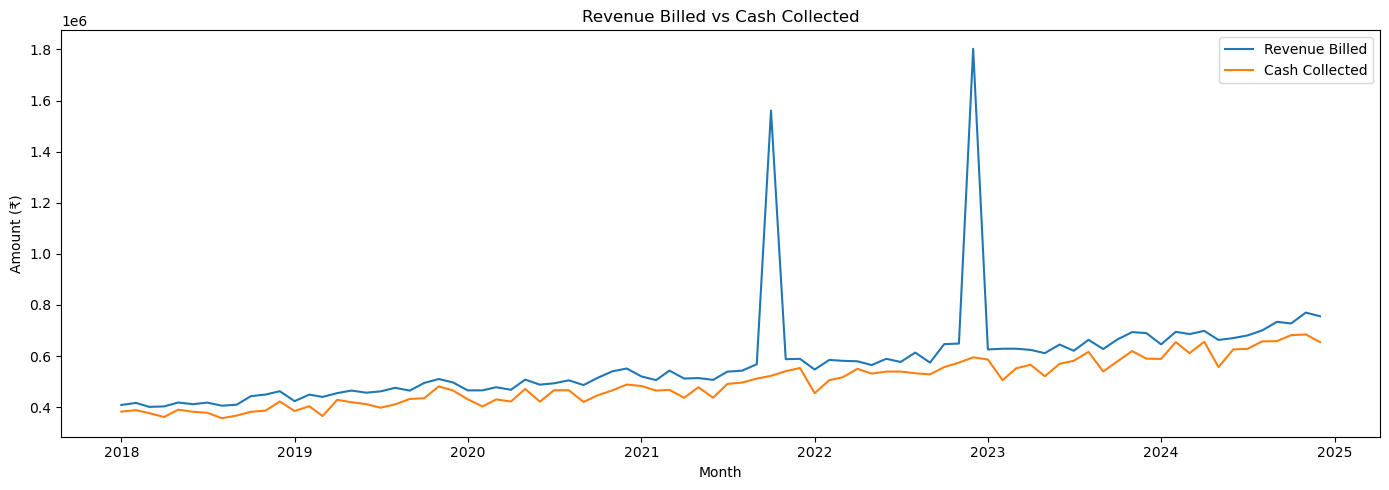

In [22]:
import matplotlib.dates as mdates

plt.figure(figsize=(14,5))

plt.plot(df['month'], df['revenue_billed'], label='Revenue Billed')
plt.plot(df['month'], df['cash_collected'], label='Cash Collected')

plt.title('Revenue Billed vs Cash Collected')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### Insight

Revenue increased over time, while cash collected consistently remained below billed revenue, indicating a persistent gap between invoicing and cash realization.

### Cash Balance Over Time
#### Is the business maintaining a healthy cash balance?

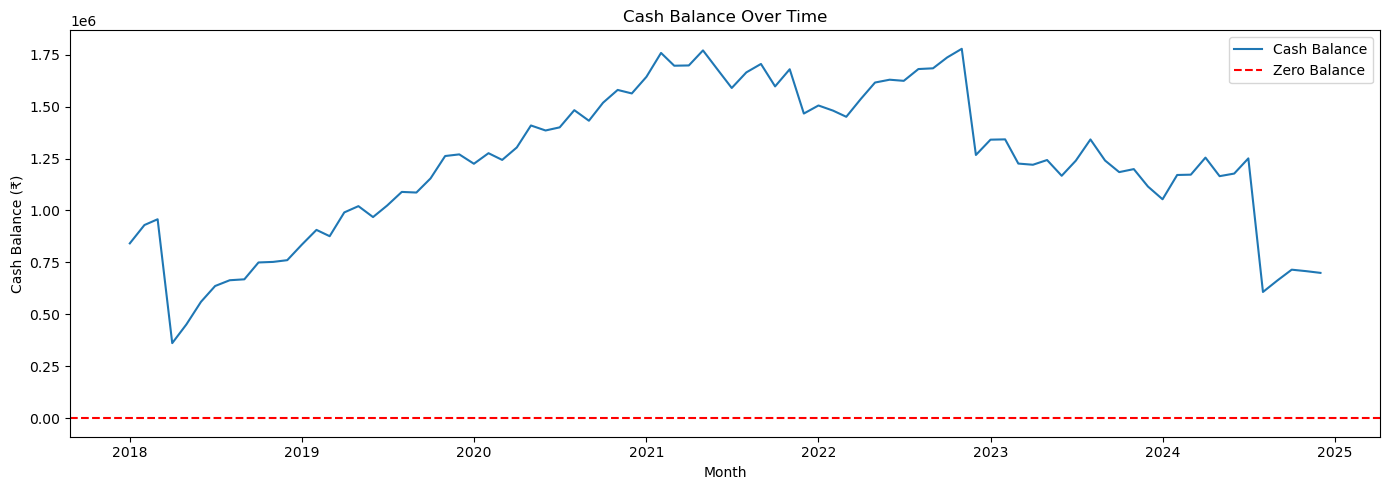

In [23]:
plt.figure(figsize=(14,5))

plt.plot(df['month'], df['cash_balance'], label='Cash Balance')
plt.axhline(0, color='red', linestyle='--', label='Zero Balance')

plt.fill_between(df['month'], df['cash_balance'], 0, where=df['cash_balance'] < 0, alpha=0.3)

plt.title('Cash Balance Over Time')
plt.xlabel('Month')
plt.ylabel('Cash Balance (₹)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.tight_layout()
plt.show()

### Insight

Cash balance never actually turns negative across the 7-year period — the lowest point is ₹3.6L (Apr-2018), tied to a single large one-off expense that month. It drifts gradually lower for most of 2021–2024 despite revenue growing every year, which matters more than any single dip.

### Profit vs Net Cash Flow
#### Does accounting profitability accurately reflect the cash position?


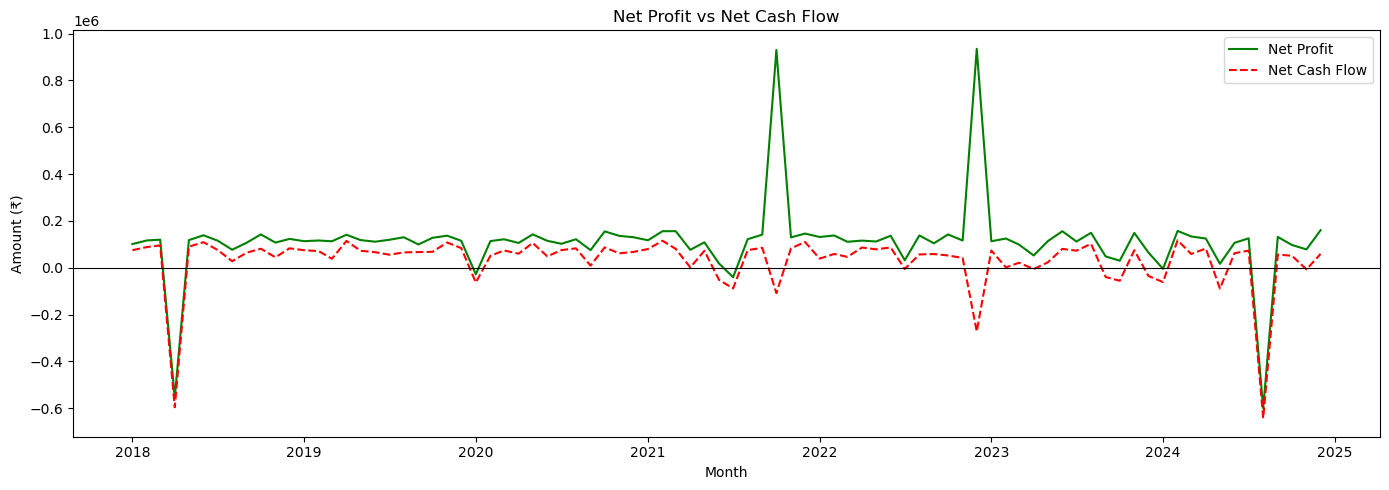

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(df['month'], df['net_profit'], label='Net Profit', color='green')
plt.plot(df['month'], df['cash_collected'] - df['total_operating_expense'],
         label='Net Cash Flow', color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.title('Net Profit vs Net Cash Flow')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.legend()
plt.tight_layout()
plt.show()

#### Insight

Profit exceeded cash flow in most months, indicating that delayed collections reduced available cash despite profitable operations.

### Expense Breakdown
#### Which cost category poses the greatest financial burden?

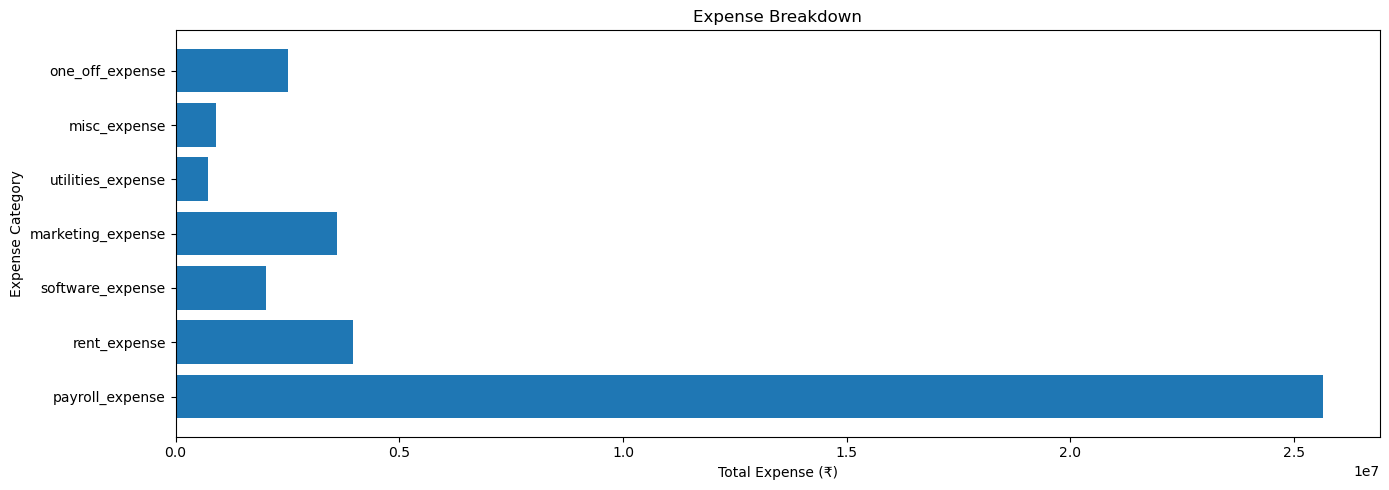

In [25]:
expense_cols = ['payroll_expense', 'rent_expense', 'software_expense', 'marketing_expense', 'utilities_expense', 'misc_expense', 'one_off_expense']
expense_total = df[expense_cols].sum()

plt.figure(figsize=(14,5))

plt.barh(expense_total.index, expense_total)

plt.title("Expense Breakdown")
plt.xlabel("Total Expense (₹)")
plt.ylabel("Expense Category")

plt.tight_layout()
plt.show()

#### Insight

Payroll accounted for the largest share of operating expenses by a wide margin, making employee costs the primary driver of the company's overall expenditure.

### Monthly Operating Expenses
#### Is the business maintaining cost discipline as it scales?

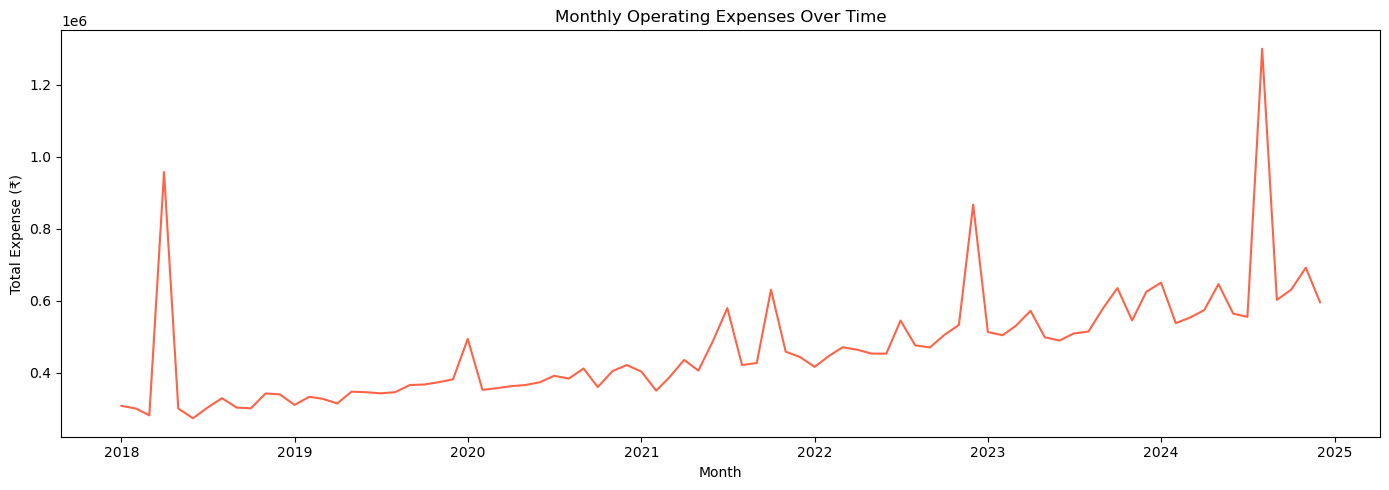

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(df['month'], df['total_operating_expense'], color='tomato', linewidth=1.5)
plt.title('Monthly Operating Expenses Over Time')
plt.xlabel('Month')
plt.ylabel('Total Expense (₹)')
plt.tight_layout()
plt.show()

#### Insight
Operating expenses trend upward across the entire 2018–2024 period, broadly tracking headcount and revenue growth, not just the recent years.

### Revenue vs Net Profit
#### Does higher revenue consistently lead to higher profitability?

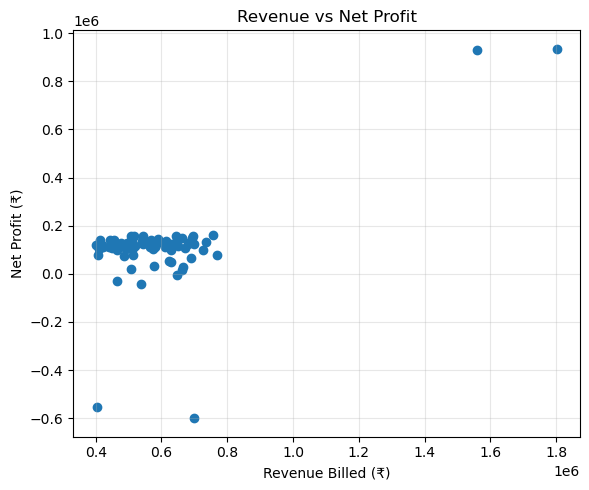

In [27]:
plt.figure(figsize=(6,5))

plt.scatter(df['revenue_billed'], df['net_profit'])

plt.title("Revenue vs Net Profit")
plt.xlabel("Revenue Billed (₹)")
plt.ylabel("Net Profit (₹)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Insight

- Net profit generally increases with revenue, indicating a positive relationship.
- Variations at similar revenue levels suggest profitability is influenced by operating costs.
- Higher revenue does not always translate into proportionally higher profit.

### Annual Cash In vs Cash Out
#### Is the business generating sufficient inflows to cover outflows year on year?

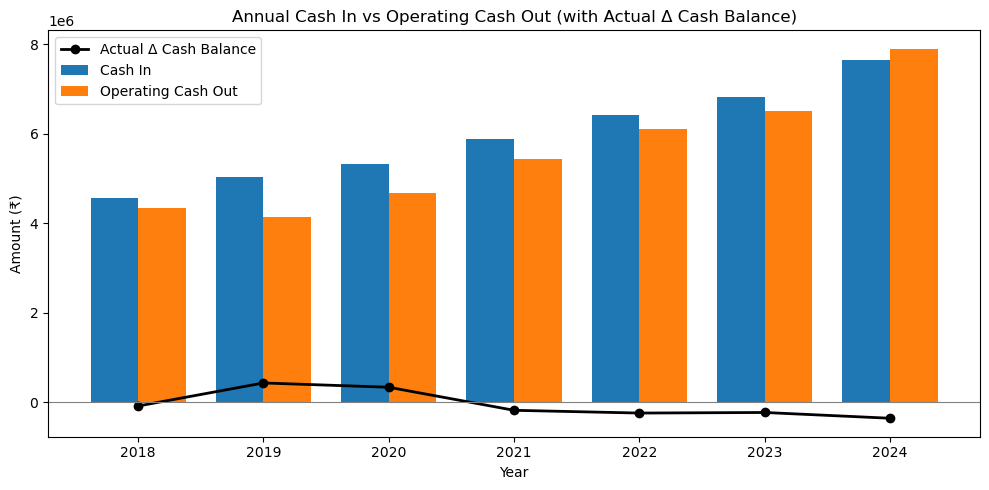

         Cash In  Operating Cash Out  Actual Δ Cash Balance
month                                                      
2018   4574065.0           4336325.0               -80892.0
2019   5036823.0           4152227.0               434374.0
2020   5333016.0           4674690.0               338464.0
2021   5882468.0           5428824.0              -176674.0
2022   6424867.0           6098301.0              -238240.0
2023   6826663.0           6513930.0              -225535.0
2024   7658683.0           7900417.0              -354299.0


In [28]:
annual = df.groupby(df['month'].dt.year)[['cash_collected', 'total_operating_expense']].sum()
annual.columns = ['Cash In', 'Operating Cash Out']

cash_by_year = df.groupby(df['month'].dt.year)['cash_balance'].agg(['first', 'last'])
annual['Actual Δ Cash Balance'] = cash_by_year['last'] - cash_by_year['first']

x = np.arange(len(annual))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, annual['Cash In'], width, label='Cash In')
ax.bar(x + width/2, annual['Operating Cash Out'], width, label='Operating Cash Out')
ax.plot(x, annual['Actual Δ Cash Balance'], color='black', marker='o', linewidth=2, label='Actual Δ Cash Balance')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(annual.index)
ax.set_title('Annual Cash In vs Operating Cash Out (with Actual Δ Cash Balance)')
ax.set_xlabel('Year'); ax.set_ylabel('Amount (₹)')
ax.legend()
plt.tight_layout()
plt.show()
print(annual.round(0))

#### Insight

* Cash In beat Operating Cash Out every year, but Actual Cash Balance still fell in 5 of 7 years, exposing a real gap between operating performance and cash reality.
* The gap widens over time: 2024 shows the steepest decline (-₹3.5L), despite being the highest-revenue year.
* Non-operating outflows, not weak operations, are the real drag, and deserve explicit budgeting, not just an operating expense fix.

### Days Sales Outstanding Over Time
#### Is the business collecting receivables within a healthy timeframe?

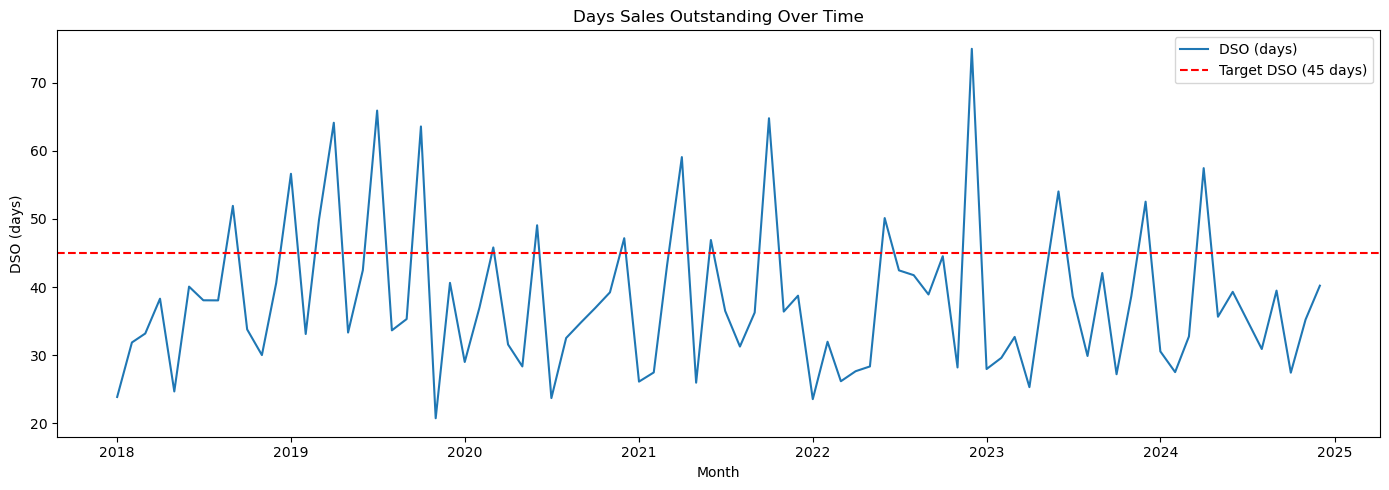

In [29]:
plt.figure(figsize=(14,5))
plt.plot(df['month'], df['DSO'], label='DSO (days)')
plt.axhline(45, color='red', linestyle='--', label='Target DSO (45 days)')
plt.title('Days Sales Outstanding Over Time')
plt.xlabel('Month')
plt.ylabel('DSO (days)')
plt.legend()
plt.tight_layout()
plt.show()

#### Insight

* DSO holds at ~38 days, comfortably inside the 45-day target, signalling healthy collections discipline.
* Spikes cluster around quarter-end, reflecting a timing pattern rather than a structural risk.
* Peaks of 70–75 days trace back to two large, unpaid invoices, isolated events rather than a systemic collection problem.

In [30]:
print('       BUSINESS SUMMARY (2018 - 2024)')
print(f'Revenue Growth     : ₹{df["revenue_billed"].iloc[0]:,.0f} → ₹{df["revenue_billed"].iloc[-1]:,.0f}')
print(f'Avg Collection Rate: {df["collection_rate"].mean():.1%}')
print(f'Profitable Months  : {(df["net_profit"] > 0).sum()} / {len(df)}')
print(f'Avg Net Profit     : ₹{df["net_profit"].mean():,.0f}')
print(f'Peak Cash Balance  : ₹{df["cash_balance"].max():,.0f}')
print(f'Lowest Cash Balance: ₹{df["cash_balance"].min():,.0f}')

       BUSINESS SUMMARY (2018 - 2024)
Revenue Growth     : ₹408,767 → ₹755,825
Avg Collection Rate: 88.6%
Profitable Months  : 79 / 84
Avg Net Profit     : ₹112,546
Peak Cash Balance  : ₹1,778,234
Lowest Cash Balance: ₹361,576


### Time Series Decomposition

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [32]:
# dropping duplicate months before setting index
df = df.drop_duplicates(subset=['month'])

# setting month as index with monthly frequency
ts_revenue = df.set_index('month')['revenue_billed'].asfreq('MS')
ts_profit  = df.set_index('month')['net_profit'].asfreq('MS')
ts_cash    = df.set_index('month')['cash_balance'].asfreq('MS')

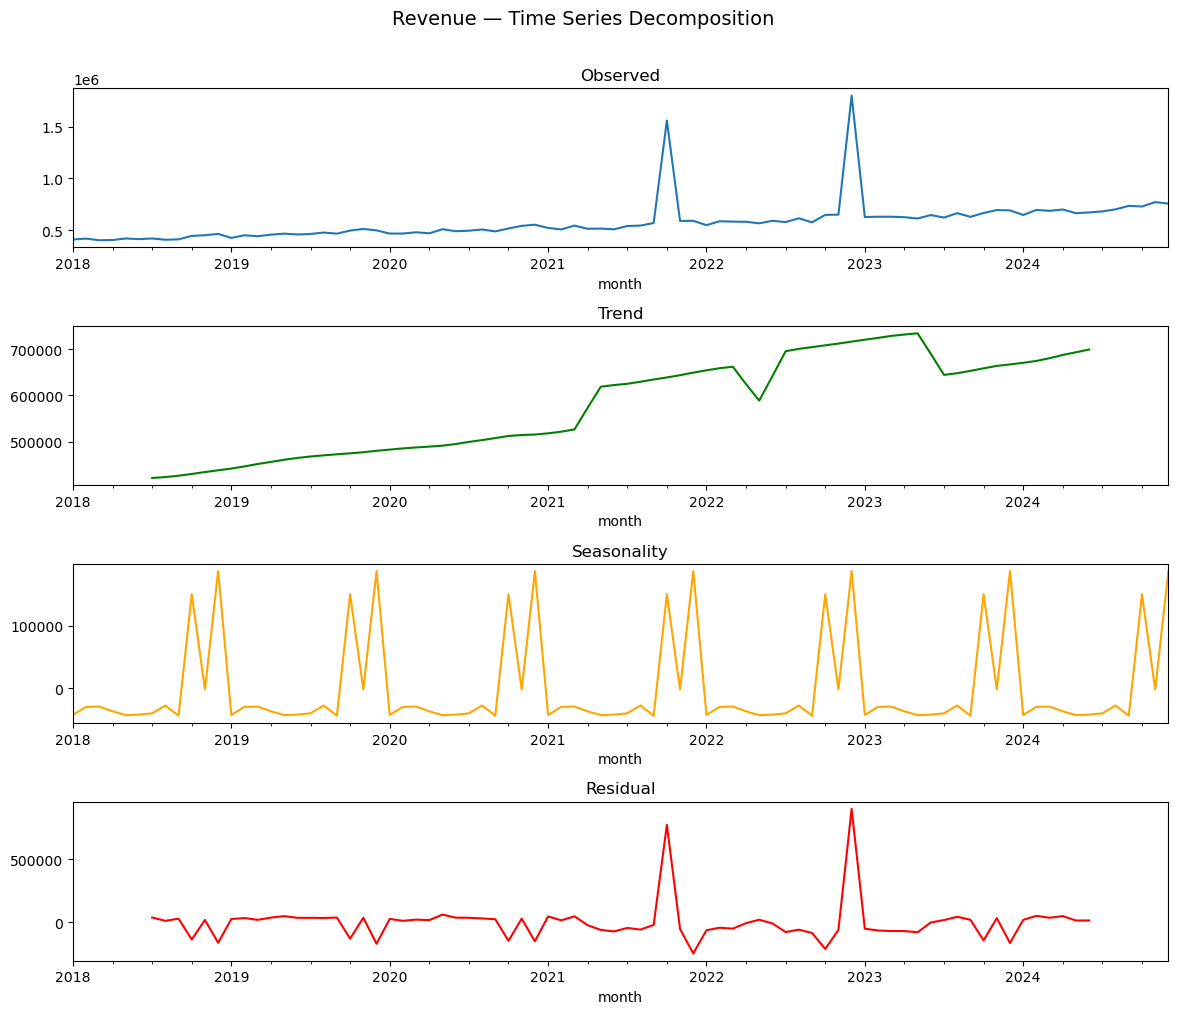

In [33]:
# breaking revenue into trend, seasonality and noise
decomp = seasonal_decompose(ts_revenue, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend', color='green')
decomp.seasonal.plot(ax=axes[2], title='Seasonality', color='orange')
decomp.resid.plot(ax=axes[3], title='Residual', color='red')

plt.suptitle('Revenue — Time Series Decomposition', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
# pulling out the key numbers from the decomposition
trend = decomp.trend.dropna()
best_month  = decomp.seasonal.groupby(decomp.seasonal.index.month).mean().idxmax()
worst_month = decomp.seasonal.groupby(decomp.seasonal.index.month).mean().idxmin()

print(f"Trend Start  : ₹{trend.iloc[0]:,.2f}")
print(f"Trend End    : ₹{trend.iloc[-1]:,.2f}")
print(f"Overall Trend: {'Upward' if trend.iloc[-1] > trend.iloc[0] else 'Downward'}")
print(f"Best Month   : {best_month}")
print(f"Worst Month  : {worst_month}")

Trend Start  : ₹421,278.03
Trend End    : ₹699,488.55
Overall Trend: Upward
Best Month   : 12
Worst Month  : 9


#### Insight

Revenue's underlying trend nearly doubles over the period, rising from ~₹4.2L to ~₹7.0L, confirming the growth is real and not noise. December is consistently the strongest month and September the weakest, a seasonal pattern worth building into cash reserve timing. The residual component still carries the two large anomaly spikes (Oct-2021, Dec-2022), so trend and seasonality alone don't explain everything.

### Anomaly Detection

In [35]:
# flagging anomalies using the IQR method
Q1 = df['net_profit'].quantile(0.25)
Q3 = df['net_profit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['is_anomaly_iqr'] = (df['net_profit'] < lower_bound) | (df['net_profit'] > upper_bound)

print("Anomalies flagged by IQR:", df['is_anomaly_iqr'].sum())
print(df[df['is_anomaly_iqr']][['month', 'net_profit']])

Anomalies flagged by IQR: 13
        month  net_profit
3  2018-04-01  -554748.23
24 2020-01-01   -28164.14
41 2021-06-01    18233.43
42 2021-07-01   -40564.78
45 2021-10-01   930188.51
54 2022-07-01    32070.22
59 2022-12-01   935159.92
63 2023-04-01    52396.55
68 2023-09-01    48346.21
69 2023-10-01    29994.98
72 2024-01-01    -4532.28
76 2024-05-01    16791.90
79 2024-08-01  -600308.99


In [36]:
# double checking with a z-score version too
ts_profit_clean = ts_profit.copy()

zscore = (ts_profit_clean - ts_profit_clean.mean()) / ts_profit_clean.std()
is_anomaly = zscore.abs() > 2

print(' Anomalous Months:', is_anomaly.sum())
print(ts_profit_clean[is_anomaly])

 Anomalous Months: 4
month
2018-04-01   -554748.23
2021-10-01    930188.51
2022-12-01    935159.92
2024-08-01   -600308.99
Name: net_profit, dtype: float64


In [37]:
# flagging anomalies using z-scores instead
df['profit_zscore'] = (df['net_profit'] - df['net_profit'].mean()) / df['net_profit'].std()
df['is_anomaly']    = df['profit_zscore'].abs() > 2

print('Anomalous months:', df['is_anomaly'].sum())
print(df[df['is_anomaly']][['month', 'net_profit', 'profit_zscore']])

Anomalous months: 4
        month  net_profit  profit_zscore
3  2018-04-01  -554748.23      -3.899842
45 2021-10-01   930188.51       4.778516
59 2022-12-01   935159.92       4.807570
79 2024-08-01  -600308.99      -4.166111


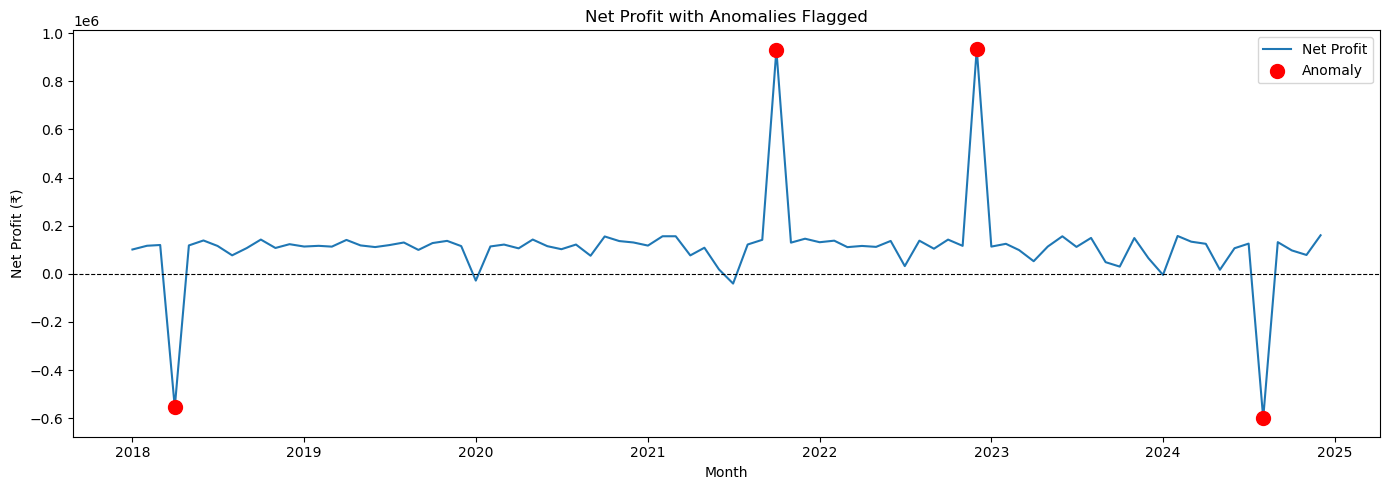

In [38]:
# plotting net profit with the anomalies marked
plt.figure(figsize=(14, 5))
plt.plot(df['month'], df['net_profit'], label='Net Profit', linewidth=1.5)
plt.scatter(df[df['is_anomaly']]['month'],
            df[df['is_anomaly']]['net_profit'],
            color='red', s=100, zorder=5, label='Anomaly')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Net Profit with Anomalies Flagged')
plt.xlabel('Month')
plt.ylabel('Net Profit (₹)')
plt.legend()
plt.tight_layout()
plt.show()

#### Insight

Z-score flags 4 genuine outliers: two one-off expense shocks (Apr-2018, Aug-2024) and two revenue spikes with delayed collection (Oct-2021, Dec-2022). IQR flags 13, a much wider net that catches normal month-to-month variability rather than true anomalies, which is why z-score is the better filter here. All 4 confirmed anomalies trace to specific, one-time events rather than a deteriorating trend, which is reassuring for forecasting.

| Date | Profit | Why Anomalous |
|------|--------|---------------|
| Apr 2018 | -₹554,748 | One-off expense of ₹655K |
| Oct 2021 | ₹930,188 | Revenue spike with delayed collection |
| Dec 2022 | ₹935,160 | Year-end revenue spike |
| Aug 2024 | -₹600,309 | Another one-off expense |

### Forecasting

In [39]:
ts = ts_revenue.copy()

# splitting into train and test sets for forecasting
train = ts.iloc[:78]
test  = ts.iloc[78:]

print('Train:', len(train), 'months')
print('Test :', len(test), 'months')
print('Train period:', train.index[0].date(), '→', train.index[-1].date())
print('Test period :', test.index[0].date(), '→', test.index[-1].date())

Train: 78 months
Test : 6 months
Train period: 2018-01-01 → 2024-06-01
Test period : 2024-07-01 → 2024-12-01


In [40]:
# running a stationarity test before modelling
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(ts)
print('ADF Statistic:', result_adf[0])
print('p-value:', result_adf[1])
if result_adf[1] > 0.05:
    print("Series is non-stationary; differencing may be needed.")
else:
    print("Series is stationary.")

ADF Statistic: -6.710355708229799
p-value: 3.6940759165981918e-09
Series is stationary.


In [41]:
# fitting an arima model on the training data
model  = ARIMA(train, order=(1, 1, 1))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:         revenue_billed   No. Observations:                   78
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1045.258
Date:                Mon, 03 Aug 2026   AIC                           2096.516
Time:                        18:52:38   BIC                           2103.547
Sample:                    01-01-2018   HQIC                          2099.328
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0191      0.271      0.071      0.944      -0.512       0.550
ma.L1         -0.8773      0.142     -6.200      0.000      -1.155      -0.600
sigma2      4.186e+10   1.33e-11   3.14e+21      0.0

In [42]:
# forecasting 6 months ahead
forecast_obj = result.get_forecast(steps=6)
forecast     = forecast_obj.predicted_mean
conf_int     = forecast_obj.conf_int()

# aligning forecast index with test dates
forecast.index = test.index
conf_int.index = test.index

In [43]:
# fitting a seasonal arima model to compare against
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(1,1,1)(1,1,0,12) – seasonal period=12
model_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12))
result_sarima = model_sarima.fit(disp=False)
print(result_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                      revenue_billed   No. Observations:                   78
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                -901.721
Date:                             Mon, 03 Aug 2026   AIC                           1811.443
Time:                                     18:52:38   BIC                           1820.140
Sample:                                 01-01-2018   HQIC                          1814.875
                                      - 06-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0466      0.305      0.153      0.879      -0.551       0.645
ma.L1         -0.8319      

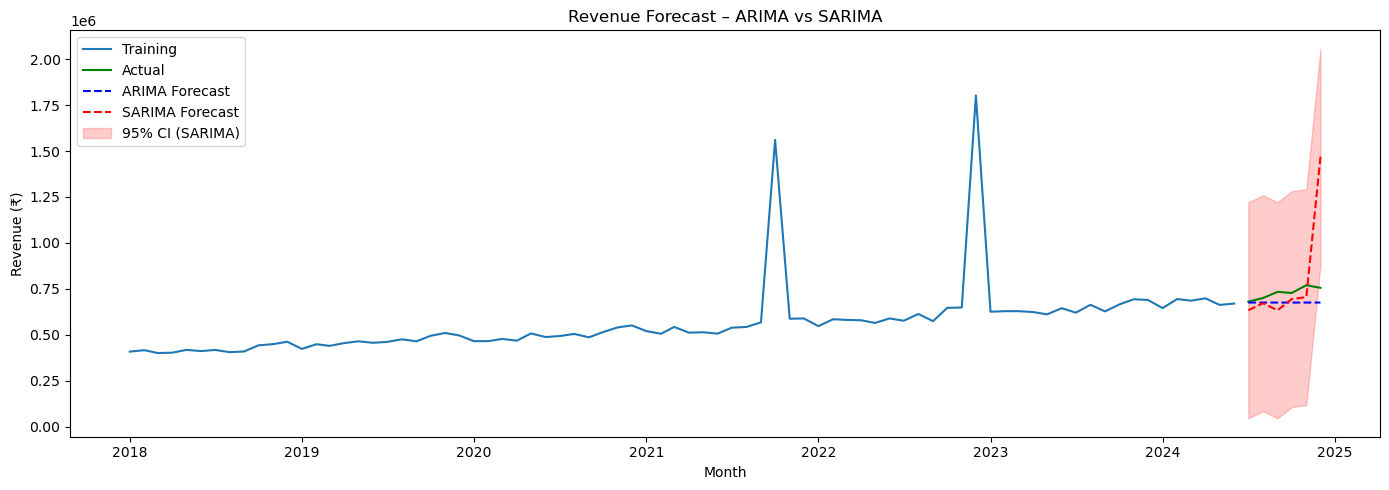

=== Model Comparison ===
ARIMA  -> MAE: 52,333, RMSE: 60,575
SARIMA -> MAE: 164,394, RMSE: 296,269


In [44]:
# plotting both forecasts against actual and comparing errors
# --- ARIMA forecast ---
forecast_arima = result.forecast(steps=len(test))   # ARIMA forecast

# --- SARIMA forecast ---
forecast_sarima = result_sarima.forecast(steps=len(test))   # SARIMA forecast

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual', color='green')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='blue', linestyle='--')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast', color='red', linestyle='--')
plt.fill_between(test.index, 
                 forecast_sarima - 1.96*np.std(forecast_sarima), 
                 forecast_sarima + 1.96*np.std(forecast_sarima),
                 alpha=0.2, color='red', label='95% CI (SARIMA)')
plt.title('Revenue Forecast – ARIMA vs SARIMA')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.tight_layout()
plt.show()

# computing metrics 
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mae_sarima = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))

print("=== Model Comparison ===")
print(f"ARIMA  -> MAE: {mae_arima:,.0f}, RMSE: {rmse_arima:,.0f}")
print(f"SARIMA -> MAE: {mae_sarima:,.0f}, RMSE: {rmse_sarima:,.0f}")

#### Interpreting the Forecast Chart
The full 7-year view compresses the 6-month forecast window against the scale of the two revenue spikes, making both forecasts look closer than the metrics suggest. MAE and RMSE, measured directly on the holdout, are the more reliable read here: ARIMA stays closer to actual on average, while SARIMA's wider confidence band reflects real uncertainty in its trend estimate. The metrics, not the visual, are what this comparison is decided on.

In [45]:
# cross validating with a rolling time series split
from sklearn.model_selection import TimeSeriesSplit

# splitting the data into 5 train/test folds
tscv = TimeSeriesSplit(n_splits=5)

mae_list = []
rmse_list = []

for train_idx, test_idx in tscv.split(ts):
    train_cv = ts.iloc[train_idx]
    test_cv = ts.iloc[test_idx]

    # SARIMA needs at least 24 months of data to work (2 full years)
    # so skipping any fold that's too short
    if len(train_cv) < 24:
        continue

    # fitting the model and forecast
    model_cv = SARIMAX(train_cv, order=(1,1,1), seasonal_order=(1,1,0,12))
    res_cv = model_cv.fit(disp=False)
    pred_cv = res_cv.forecast(steps=len(test_cv))

    # saving the error for this fold
    mae = mean_absolute_error(test_cv, pred_cv)
    rmse = np.sqrt(mean_squared_error(test_cv, pred_cv))
    mae_list.append(mae)
    rmse_list.append(rmse)

print("Average MAE:", np.mean(mae_list))
print("Average RMSE:", np.mean(rmse_list))

Average MAE: 123345.50069992052
Average RMSE: 247270.95741384852


#### Why ARIMA Over SARIMA?

ARIMA(1,1,1) wins because there isn't enough data for SARIMA to learn seasonality reliably; 78 months is only 6.5 seasonal cycles, too few for a 12-month term to separate signal from noise. Cross-validation confirms this isn't a fluke: SARIMA's holdout error (₹164,394 MAE) matches its 5-fold average (₹123,345), a consistent weakness. With limited history, the simpler model generalizes better, exactly what the ~3x lower error shows.

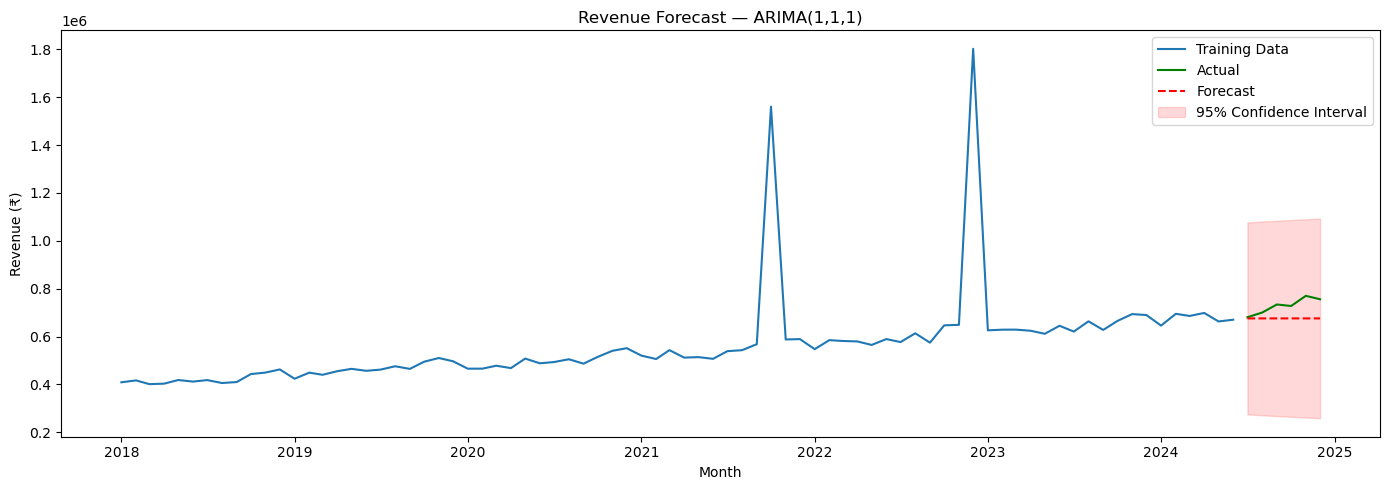

In [46]:
# zooming in on the arima forecast with its confidence interval
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual', color='green')
plt.plot(forecast.index, forecast, label='Forecast',
         color='red', linestyle='--')
plt.fill_between(forecast.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.15, label='95% Confidence Interval')
plt.title('Revenue Forecast — ARIMA(1,1,1)')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# checking the final forecast accuracy numbers
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
print('=== Forecast Accuracy ===')
print(f'MAE  : ₹{mae:,.0f}')
print(f'RMSE : ₹{rmse:,.0f}')
print(f"MAPE : {mape:.1f}%")

=== Forecast Accuracy ===
MAE  : ₹52,333
RMSE : ₹60,575
MAPE : 7.0%


#### A Note on MAPE

MAPE is shown for reference, not as the primary metric. Revenue stays well above zero, so it won't blow up here, but it still weighs a small miss in a low-revenue month the same as a large miss in a high-revenue one, understating what matters for cash planning. MAE and RMSE, in rupee terms, remain the metrics this analysis relies on.

## Model Comparison & Business Implications

| Metric | ARIMA(1,1,1) | SARIMA(1,1,1)(1,1,0,12) |
|--------|--------------|--------------------------|
| MAE    | ₹52,333      | ₹164,394                 |
| RMSE   | ₹60,575      | ₹296,269                 |
| CV Avg MAE (5-fold) | — | ₹123,345         |
| Seasonality | Not captured | Captured             |

**Key Takeaway:** ARIMA(1,1,1) beats SARIMA on both the single holdout and 5-fold cross-validation. With only 78 training months, SARIMA's 12-month seasonal term doesn't have enough repeated cycles to generalize — it overfits the training seasonality. ARIMA is the safer choice for production forecasting here.

**Recommendations:**
1. **Improve collections** – DSO currently averages 38 days; already inside the ≤45-day target.
2. **Build cash reserve** – maintain at least 1 month of expenses; cash ratio averages ~2.8 months but dipped to ~0.4 at its low.
3. **Plan for non-operating cash drag** – tax and owner draws cost ₹1–6L/year in cash balance even in profitable years; operating profit doesn't convert 1:1 to cash.
4. **Refresh the forecast quarterly** – update ARIMA every 3 months as new actuals arrive.
5. **Link hiring to the forecast, checked against DSO/cash ratio** – so headcount growth doesn't outpace actual cash collection.